# **k-means**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving total before kmean2.csv to total before kmean2 (1).csv


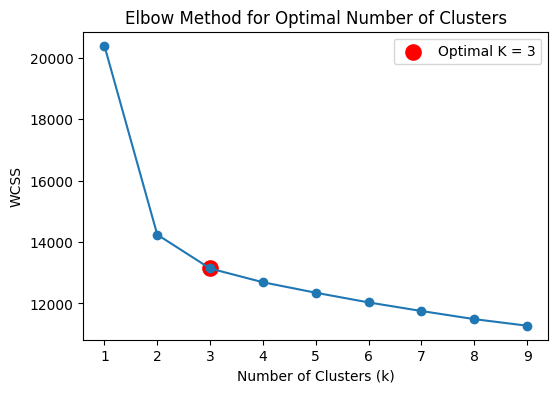

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
K = range(1,10)

for k in K:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))

plt.plot(K, wcss, marker='o')

# ทำเครื่องหมาย optimal k
plt.scatter(3, wcss[2], color='red', s=120, label='Optimal K = 3')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal Number of Clusters')

plt.legend()

plt.show()

# **one-way anova**

In [ ]:
variables = ['Product','Price','Place','Promotion']

f_values=[]
p_values=[]

for v in variables:

    c0 = df[df['Cluster']==0][v]
    c1 = df[df['Cluster']==1][v]
    c2 = df[df['Cluster']==2][v]

    f,p = stats.f_oneway(c0,c1,c2)

    f_values.append(f)
    p_values.append(p)

In [ ]:
anova_table = pd.DataFrame({
    'Factor': ['Product','Price','Place','Promotion'],
    'F': f_values,
    'p-value': p_values
})

anova_table

,Factor,F,p-value
0,Product,1223.305881,4.596104e-290
1,Price,1605.268176,0.000000e+00
2,Place,1188.113655,5.401983e-285
3,Promotion,852.941455,5.443549e-231


In [ ]:
with pd.ExcelWriter('kmeans_anova_result.xlsx') as writer:

    df.to_excel(writer, sheet_name='Clustered_Data', index=False)

    cluster_mean.to_excel(writer, sheet_name='Cluster_Mean')

    anova_table.to_excel(writer, sheet_name='ANOVA_Result', index=False)

In [ ]:
from google.colab import files
files.download('kmeans_anova_result.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **random forest**

# Group 1



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving G1-rdf.csv to G1-rdf.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# โหลดข้อมูล
df = pd.read_csv("G1-rdf.csv", header=None)

data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

# กลุ่มตัวแปร
groups = {
"product": product,
"price": price,
"place": place,
"promotion": promotion
}

# สร้างโฟลเดอร์เก็บกราฟ
os.makedirs("importance_graphs", exist_ok=True)

count = 1

for gname, X in groups.items():

    for i, ycol in enumerate(Y.columns):

        y = Y[ycol]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        model = RandomForestClassifier(random_state=42)

        model.fit(X_train, y_train)

        importance = model.feature_importances_

        importance_df = pd.DataFrame({
            "Question": [f"Question {i+1}" for i in range(len(X.columns))],
            "Importance": importance
        })

        # เรียงลำดับ
        importance_df = importance_df.sort_values(
            by="Importance",
            ascending=True
        )

        plt.figure(figsize=(7,4))

        bars = plt.barh(
            importance_df["Question"],
            importance_df["Importance"]
        )

        # ใส่ตัวเลข importance ปลายกราฟ
        for bar in bars:
            width = bar.get_width()
            plt.text(width + 0.001,
                     bar.get_y() + bar.get_height()/2,
                     f"{width:.3f}",
                     va='center')

        plt.title(f"Group 1{gname} with Variable Y{i+1}", fontsize=12)

        plt.xlabel("Feature Importance")
        plt.ylabel(f"{gname}")

        plt.grid(axis='x', linestyle='--', alpha=0.6)

        plt.tight_layout()

        plt.savefig(f"importance_graphs/graph_{count}.png", dpi=300)

        plt.close()

        count += 1

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("feature_importance_graphs",'zip',"importance_graphs")

files.download("feature_importance_graphs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Group 2

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving G2-rfd.csv to G2-rfd.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# โหลดไฟล์
df = pd.read_csv("G2-rfd.csv", header=None)

# ลบ 3 แถวแรก
data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

# กลุ่มตัวแปร
groups = {
"Product": product,
"Price": price,
"Place": place,
"Promotion": promotion
}

# สร้างโฟลเดอร์
os.makedirs("importance_graphs_G2", exist_ok=True)

count = 1

for gname, X in groups.items():

    for i, ycol in enumerate(Y.columns):

        y = Y[ycol]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        model = RandomForestClassifier(random_state=42)

        model.fit(X_train, y_train)

        importance = model.feature_importances_

        importance_df = pd.DataFrame({
            "Question": [f"Question {i+1}" for i in range(len(X.columns))],
            "Importance": importance
        })

        importance_df = importance_df.sort_values(
            by="Importance",
            ascending=True
        )

        plt.figure(figsize=(7,4))

        bars = plt.barh(
            importance_df["Question"],
            importance_df["Importance"]
        )

        # ใส่ตัวเลข importance
        for bar in bars:
            width = bar.get_width()
            plt.text(width + 0.001,
                     bar.get_y() + bar.get_height()/2,
                     f"{width:.3f}",
                     va='center')

        plt.title(f"Group 2: {gname} vs Variable Y{i+1}", fontsize=12)

        plt.xlabel("Feature Importance")
        plt.ylabel(f"{gname}")

        plt.grid(axis='x', linestyle='--', alpha=0.6)

        plt.tight_layout()

        plt.savefig(f"importance_graphs_G2/graph_{count}.png", dpi=300)

        plt.close()

        count += 1

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("feature_importance_graphs_G2",'zip',"importance_graphs_G2")

files.download("feature_importance_graphs_G2.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Group 3

Saving G3-rfd.csv to G3-rfd.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# โหลดไฟล์
df = pd.read_csv("G3-rfd.csv", header=None)

# ลบ 3 แถวแรก
data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

# กลุ่มตัวแปร
groups = {
"Product": product,
"Price": price,
"Place": place,
"Promotion": promotion
}

# สร้างโฟลเดอร์
os.makedirs("importance_graphs_G3", exist_ok=True)

count = 1

for gname, X in groups.items():

    for i, ycol in enumerate(Y.columns):

        y = Y[ycol]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        model = RandomForestClassifier(random_state=42)

        model.fit(X_train, y_train)

        importance = model.feature_importances_

        importance_df = pd.DataFrame({
            "Question": [f"Question {i+1}" for i in range(len(X.columns))],
            "Importance": importance
        })

        importance_df = importance_df.sort_values(
            by="Importance",
            ascending=True
        )

        plt.figure(figsize=(7,4))

        bars = plt.barh(
            importance_df["Question"],
            importance_df["Importance"]
        )

        # ใส่ตัวเลข importance ปลายแท่ง
        for bar in bars:
            width = bar.get_width()
            plt.text(width + 0.001,
                     bar.get_y() + bar.get_height()/2,
                     f"{width:.3f}",
                     va='center')

        plt.title(f"Group 3: {gname} vs Variable Y{i+1}", fontsize=12)

        plt.xlabel("Feature Importance")
        plt.ylabel(f"{gname}")

        plt.grid(axis='x', linestyle='--', alpha=0.6)

        plt.tight_layout()

        plt.savefig(f"importance_graphs_G3/graph_{count}.png", dpi=300)

        plt.close()

        count += 1

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("feature_importance_graphs_G3",'zip',"importance_graphs_G3")

files.download("feature_importance_graphs_G3.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Accuracy/F1**

# Group 1

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# โหลดไฟล์ Group 1
df = pd.read_csv("G1-rdf.csv", header=None)

# ลบ 3 แถวแรก
data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

groups = {
    "Product": product,
    "Price": price,
    "Place": place,
    "Promotion": promotion
}

results = []

for gname, X in groups.items():

    for i, ycol in enumerate(Y.columns):

        y = Y[ycol]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        model = RandomForestClassifier(random_state=42)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        results.append({
            "Model": f"{gname} - Y{i+1}",
            "Accuracy": round(accuracy,3),
            "Precision": round(precision,3),
            "Recall": round(recall,3),
            "F1-score": round(f1,3)
        })

results_df = pd.DataFrame(results)

print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

             Model  Accuracy  Precision  Recall  F1-score
0     Product - Y1     0.575      0.569   0.575     0.558
1     Product - Y2     0.550      0.537   0.550     0.542
2     Product - Y3     0.406      0.386   0.406     0.394
3       Price - Y1     0.556      0.558   0.556     0.543
4       Price - Y2     0.594      0.579   0.594     0.586
5       Price - Y3     0.487      0.465   0.487     0.474
6       Place - Y1     0.500      0.508   0.500     0.427
7       Place - Y2     0.537      0.501   0.537     0.487
8       Place - Y3     0.456      0.334   0.456     0.378
9   Promotion - Y1     0.600      0.566   0.600     0.581
10  Promotion - Y2     0.537      0.517   0.537     0.526
11  Promotion - Y3     0.512      0.504   0.512     0.463


In [ ]:
results_df.to_excel("Group1_Model_Performance.xlsx", index=False)

In [ ]:
from google.colab import files
files.download("Group1_Model_Performance.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Group 2

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# โหลดไฟล์ Group 2
df = pd.read_csv("G2-rfd.csv", header=None)

# ลบ 3 แถวแรก
data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

groups = {
"Product": product,
"Price": price,
"Place": place,
"Promotion": promotion
}

results = []

for gname, X in groups.items():

    for i, ycol in enumerate(Y.columns):

        y = Y[ycol]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        model = RandomForestClassifier(random_state=42)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        results.append({
            "Model": f"{gname} - Y{i+1}",
            "Accuracy": round(accuracy,3),
            "Precision": round(precision,3),
            "Recall": round(recall,3),
            "F1-score": round(f1,3)
        })

results_df = pd.DataFrame(results)

print(results_df)

             Model  Accuracy  Precision  Recall  F1-score
0     Product - Y1     0.229      0.253   0.229     0.229
1     Product - Y2     0.188      0.181   0.188     0.174
2     Product - Y3     0.271      0.266   0.271     0.265
3       Price - Y1     0.229      0.311   0.229     0.250
4       Price - Y2     0.198      0.226   0.198     0.191
5       Price - Y3     0.271      0.270   0.271     0.270
6       Place - Y1     0.250      0.236   0.250     0.240
7       Place - Y2     0.292      0.289   0.292     0.281
8       Place - Y3     0.219      0.212   0.219     0.214
9   Promotion - Y1     0.271      0.276   0.271     0.271
10  Promotion - Y2     0.271      0.246   0.271     0.254
11  Promotion - Y3     0.188      0.224   0.188     0.198


In [ ]:
results_df.to_excel("Group2_Model_Performance.xlsx", index=False)

In [ ]:
from google.colab import files
files.download("Group2_Model_Performance.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Group 3

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# โหลดไฟล์
df = pd.read_csv("G3-rfd.csv", header=None)

# ลบ 3 แถวแรก
data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

groups = {
"Product": product,
"Price": price,
"Place": place,
"Promotion": promotion
}

results = []

for gname, X in groups.items():

    for i, ycol in enumerate(Y.columns):

        y = Y[ycol]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        model = RandomForestClassifier(random_state=42)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        results.append({
            "Model": f"{gname} - Y{i+1}",
            "Accuracy": round(accuracy,3),
            "Precision": round(precision,3),
            "Recall": round(recall,3),
            "F1-score": round(f1,3)
        })

results_df = pd.DataFrame(results)

print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

             Model  Accuracy  Precision  Recall  F1-score
0     Product - Y1     0.340      0.261   0.340     0.291
1     Product - Y2     0.519      0.464   0.519     0.450
2     Product - Y3     0.396      0.394   0.396     0.374
3       Price - Y1     0.462      0.421   0.462     0.428
4       Price - Y2     0.491      0.426   0.491     0.439
5       Price - Y3     0.425      0.406   0.425     0.400
6       Place - Y1     0.387      0.346   0.387     0.335
7       Place - Y2     0.434      0.399   0.434     0.414
8       Place - Y3     0.368      0.544   0.368     0.348
9   Promotion - Y1     0.377      0.306   0.377     0.318
10  Promotion - Y2     0.500      0.477   0.500     0.449
11  Promotion - Y3     0.453      0.504   0.453     0.425


In [ ]:
results_df.to_excel("Group3_Model_Performance.xlsx", index=False)

In [ ]:
from google.colab import files
files.download("Group3_Model_Performance.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **ordinal logistic regression**

# Group 1

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving G1-rdf.csv to G1-rdf (1).csv


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel

# โหลดข้อมูล
df = pd.read_csv("G1-rdf.csv", header=None)

# ตัด 3 แถวแรก
data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

# ค่าเฉลี่ยแต่ละด้าน
data["Product"] = product.mean(axis=1)
data["Price"] = price.mean(axis=1)
data["Place"] = place.mean(axis=1)
data["Promotion"] = promotion.mean(axis=1)

# X และ Y
X = data[["Product","Price","Place","Promotion"]]
y = Y.iloc[:,0]

# สร้างโมเดล
model = OrderedModel(y, X, distr="logit")
result = model.fit(method="bfgs")

# คำนวณ Odds Ratio
coef = result.params
se = result.bse
p = result.pvalues

OR = np.exp(coef)

# Confidence Interval
conf = result.conf_int()
conf["OR_lower"] = np.exp(conf[0])
conf["OR_upper"] = np.exp(conf[1])

# สร้างตาราง
table = pd.DataFrame({
    "Variable": coef.index,
    "b": coef.values,
    "SE(b)": se.values,
    "OR": OR.values,
    "95%CI Lower": conf["OR_lower"].values,
    "95%CI Upper": conf["OR_upper"].values,
    "p-value": p.values
})

table

Optimization terminated successfully.
         Current function value: 0.868833
         Iterations: 85
         Function evaluations: 98
         Gradient evaluations: 98


,Variable,b,SE(b),OR,95%CI Lower,95%CI Upper,p-value
0,Product,0.977137,0.279764,2.656840,1.535429,4.597282,4.781325e-04
1,Price,0.933440,0.318018,2.543243,1.363612,4.743347,3.333495e-03
2,Place,0.409955,0.254969,1.506750,0.914137,2.483541,1.078651e-01
3,Promotion,0.765379,0.235100,2.149809,1.356071,3.408137,1.131733e-03
4,1.0/2.0,8.340823,2.152039,4191.539325,61.738330,284572.030363,1.062847e-04
5,2.0/3.0,0.235156,0.474793,1.265106,0.498864,3.208274,6.204014e-01
6,3.0/4.0,0.491719,0.208944,1.635124,1.085669,2.462658,1.860503e-02
7,4.0/5.0,1.021099,0.065469,2.776245,2.441913,3.156351,7.674487e-55


In [ ]:
table.to_excel("Ordinal_Logistic_G1_Table4.xlsx", index=False)

In [ ]:
from google.colab import files
files.download("Ordinal_Logistic_G1_Table4.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Group 2

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving G2-rfd.csv to G2-rfd (2).csv


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel

# โหลดข้อมูล
df = pd.read_csv("G2-rfd.csv", header=None)

# ตัด 3 แถวแรก
data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

# ค่าเฉลี่ยแต่ละด้าน
data["Product"] = product.mean(axis=1)
data["Price"] = price.mean(axis=1)
data["Place"] = place.mean(axis=1)
data["Promotion"] = promotion.mean(axis=1)

# X และ Y
X = data[["Product","Price","Place","Promotion"]]
y = Y.iloc[:,0]

# สร้างโมเดล
model = OrderedModel(y, X, distr="logit")
result = model.fit(method="bfgs")

# คำนวณ Odds Ratio
coef = result.params
se = result.bse
p = result.pvalues

OR = np.exp(coef)

# Confidence Interval
conf = result.conf_int()
conf["OR_lower"] = np.exp(conf[0])
conf["OR_upper"] = np.exp(conf[1])

# สร้างตาราง
table = pd.DataFrame({
    "Variable": coef.index,
    "b": coef.values,
    "SE(b)": se.values,
    "OR": OR.values,
    "95%CI Lower": conf["OR_lower"].values,
    "95%CI Upper": conf["OR_upper"].values,
    "p-value": p.values
})

table

Optimization terminated successfully.
         Current function value: 1.605755
         Iterations: 26
         Function evaluations: 27
         Gradient evaluations: 27


,Variable,b,SE(b),OR,95%CI Lower,95%CI Upper,p-value
0,Product,0.093930,0.168171,1.098483,0.790033,1.527359,0.576478
1,Price,-0.088158,0.196152,0.915616,0.623374,1.344864,0.653117
2,Place,0.069155,0.143859,1.071602,0.808314,1.420650,0.630721
3,Promotion,-0.002280,0.123276,0.997722,0.783568,1.270406,0.985241
4,1.0/2.0,-1.262162,1.020135,0.283041,0.038327,2.090213,0.215994
5,2.0/3.0,-0.018349,0.119712,0.981818,0.776484,1.241452,0.878180
6,3.0/4.0,-0.089100,0.108261,0.914754,0.739865,1.130983,0.410502
7,4.0/5.0,-0.082026,0.120375,0.921248,0.727633,1.166381,0.495606


In [ ]:
table.to_excel("Ordinal_Logistic_G2_Table4.xlsx", index=False)

# Group 3

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving G3-rfd.csv to G3-rfd (1).csv


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel

# โหลดข้อมูล
df = pd.read_csv("G3-rfd.csv", header=None)

# ตัด 3 แถวแรก
data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

# ค่าเฉลี่ยแต่ละด้าน
data["Product"] = product.mean(axis=1)
data["Price"] = price.mean(axis=1)
data["Place"] = place.mean(axis=1)
data["Promotion"] = promotion.mean(axis=1)

# X และ Y
X = data[["Product","Price","Place","Promotion"]]
y = Y.iloc[:,0]

# สร้างโมเดล
model = OrderedModel(y, X, distr="logit")
result = model.fit(method="bfgs")

# คำนวณ Odds Ratio
coef = result.params
se = result.bse
p = result.pvalues

OR = np.exp(coef)

# Confidence Interval
conf = result.conf_int()
conf["OR_lower"] = np.exp(conf[0])
conf["OR_upper"] = np.exp(conf[1])

# สร้างตาราง
table = pd.DataFrame({
    "Variable": coef.index,
    "b": coef.values,
    "SE(b)": se.values,
    "OR": OR.values,
    "95%CI Lower": conf["OR_lower"].values,
    "95%CI Upper": conf["OR_upper"].values,
    "p-value": p.values
})

table

Optimization terminated successfully.
         Current function value: 1.262440
         Iterations: 35
         Function evaluations: 38
         Gradient evaluations: 38


,Variable,b,SE(b),OR,95%CI Lower,95%CI Upper,p-value
0,Product,0.692450,0.266138,1.998606,1.186289,3.367162,9.272281e-03
1,Price,0.333596,0.280780,1.395979,0.805154,2.420357,2.347917e-01
2,Place,0.584390,0.222532,1.793896,1.159786,2.774704,8.637056e-03
3,Promotion,0.344764,0.188178,1.411657,0.976229,2.041301,6.693434e-02
4,1.0/2.0,3.728351,1.838791,41.610447,1.132453,1528.919205,4.260011e-02
5,2.0/3.0,0.412794,0.224160,1.511034,0.973798,2.344657,6.554600e-02
6,3.0/4.0,0.535809,0.105798,1.708830,1.388811,2.102589,4.095913e-07
7,4.0/5.0,0.709267,0.069619,2.032501,1.773253,2.329651,2.248177e-24


In [ ]:
table.to_excel("Ordinal_Logistic_G3_Table4.xlsx", index=False)

In [ ]:
from google.colab import files
files.download("Ordinal_Logistic_G3_Table4.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **ordinal logistic regression**

# กลุ่มที่ 1

In [1]:
from google.colab import files
uploaded = files.upload()

Saving G1-olr.csv to G1-olr.csv


In [10]:
import pandas as pd
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel

# โหลดไฟล์ และลบ 3 แถวแรก
df = pd.read_csv('/content/G1-olr.csv', header=None)
df = df.iloc[3:].reset_index(drop=True)

# ตั้งชื่อคอลัมน์ใหม่
df.columns = [f"Q{i}" for i in range(1,18)] + ["Y1","Y2","Y3"]

# แปลงเป็นตัวเลข
df = df.astype(float)

# สร้างตัวแปร X (ค่าเฉลี่ยแต่ละหมวด)

df['Product'] = df[['Q1','Q2','Q3','Q4','Q5']].mean(axis=1)

df['Price'] = df[['Q6','Q7','Q8','Q9','Q10','Q11']].mean(axis=1)

df['Place'] = df[['Q12','Q13','Q14']].mean(axis=1)

df['Promotion'] = df[['Q15','Q16','Q17']].mean(axis=1)

X = df[['Product','Price','Place','Promotion']]


# ฟังก์ชันรัน Ordinal Logistic
def run_model(y_var):

    y = df[y_var]

    model = OrderedModel(y, X, distr='logit')
    result = model.fit(method='bfgs', disp=False)

    params = result.params
    se = result.bse
    p = result.pvalues

    OR = np.exp(params)

    conf = result.conf_int()
    CI_low = np.exp(conf[0])
    CI_high = np.exp(conf[1])

    table = pd.DataFrame({
        "Variable": params.index,
        "Coefficient": params.values,
        "SE": se.values,
        "Odds Ratio": OR.values,
        "CI Lower": CI_low.values,
        "CI Upper": CI_high.values,
        "p-value": p.values
    })

    # เอา threshold ออก
    table = table[~table["Variable"].str.contains("/")]

    return table


# รันโมเดล
Y1 = run_model("Y1")
Y2 = run_model("Y2")
Y3 = run_model("Y3")


# export Excel
with pd.ExcelWriter("Ordinal_Logistic_G1.xlsx") as writer:

    Y1.to_excel(writer, sheet_name="Y1", index=False)
    Y2.to_excel(writer, sheet_name="Y2", index=False)
    Y3.to_excel(writer, sheet_name="Y3", index=False)

print("เสร็จแล้ว ดาวน์โหลดไฟล์ Excel ได้เลย")

เสร็จแล้ว ดาวน์โหลดไฟล์ Excel ได้เลย


In [11]:
from google.colab import files
files.download("Ordinal_Logistic_G1.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# กลุ่มที่ 2

In [14]:
from google.colab import files
uploaded = files.upload()

Saving G2-olr.csv to G2-olr.csv


In [19]:
import pandas as pd
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel

# โหลดไฟล์ และลบ 3 แถวแรก
df = pd.read_csv('/content/G2-olr.csv', header=None)
df = df.iloc[3:].reset_index(drop=True)

# ตั้งชื่อคอลัมน์ใหม่
df.columns = [f"Q{i}" for i in range(1,18)] + ["Y1","Y2","Y3"]

# แปลงเป็นตัวเลข
df = df.astype(float)

# สร้างตัวแปร X (ค่าเฉลี่ยแต่ละหมวด)

df['Product'] = df[['Q1','Q2','Q3','Q4','Q5']].mean(axis=1)

df['Price'] = df[['Q6','Q7','Q8','Q9','Q10','Q11']].mean(axis=1)

df['Place'] = df[['Q12','Q13','Q14']].mean(axis=1)

df['Promotion'] = df[['Q15','Q16','Q17']].mean(axis=1)

X = df[['Product','Price','Place','Promotion']]


# ฟังก์ชันรัน Ordinal Logistic
def run_model(y_var):

    y = df[y_var]

    model = OrderedModel(y, X, distr='logit')
    result = model.fit(method='bfgs', disp=False)

    params = result.params
    se = result.bse
    p = result.pvalues

    OR = np.exp(params)

    conf = result.conf_int()
    CI_low = np.exp(conf[0])
    CI_high = np.exp(conf[1])

    table = pd.DataFrame({
        "Variable": params.index,
        "Coefficient": params.values,
        "SE": se.values,
        "Odds Ratio": OR.values,
        "CI Lower": CI_low.values,
        "CI Upper": CI_high.values,
        "p-value": p.values
    })

    # เอา threshold ออก
    table = table[~table["Variable"].str.contains("/")]

    return table


# รันโมเดล
Y1 = run_model("Y1")
Y2 = run_model("Y2")
Y3 = run_model("Y3")


# export Excel
with pd.ExcelWriter("Ordinal_Logistic_G2.xlsx") as writer:

    Y1.to_excel(writer, sheet_name="Y1", index=False)
    Y2.to_excel(writer, sheet_name="Y2", index=False)
    Y3.to_excel(writer, sheet_name="Y3", index=False)

print("เสร็จแล้ว ดาวน์โหลดไฟล์ Excel ได้เลย")

เสร็จแล้ว ดาวน์โหลดไฟล์ Excel ได้เลย


In [20]:
from google.colab import files
files.download("Ordinal_Logistic_G2.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# กลุ่ม 3

In [21]:
from google.colab import files
uploaded = files.upload()

Saving G3-olr.csv to G3-olr.csv


In [26]:
import pandas as pd
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel

# โหลดไฟล์ และลบ 3 แถวแรก
df = pd.read_csv('/content/G3-olr.csv', header=None)
df = df.iloc[3:].reset_index(drop=True)

# ตั้งชื่อคอลัมน์ใหม่
df.columns = [f"Q{i}" for i in range(1,18)] + ["Y1","Y2","Y3"]

# แปลงเป็นตัวเลข
df = df.astype(float)

# สร้างตัวแปร X (ค่าเฉลี่ยแต่ละหมวด)

df['Product'] = df[['Q1','Q2','Q3','Q4','Q5']].mean(axis=1)

df['Price'] = df[['Q6','Q7','Q8','Q9','Q10','Q11']].mean(axis=1)

df['Place'] = df[['Q12','Q13','Q14']].mean(axis=1)

df['Promotion'] = df[['Q15','Q16','Q17']].mean(axis=1)

X = df[['Product','Price','Place','Promotion']]


# ฟังก์ชันรัน Ordinal Logistic
def run_model(y_var):

    y = df[y_var]

    model = OrderedModel(y, X, distr='logit')
    result = model.fit(method='bfgs', disp=False)

    params = result.params
    se = result.bse
    p = result.pvalues

    OR = np.exp(params)

    conf = result.conf_int()
    CI_low = np.exp(conf[0])
    CI_high = np.exp(conf[1])

    table = pd.DataFrame({
        "Variable": params.index,
        "Coefficient": params.values,
        "SE": se.values,
        "Odds Ratio": OR.values,
        "CI Lower": CI_low.values,
        "CI Upper": CI_high.values,
        "p-value": p.values
    })

    # เอา threshold ออก
    table = table[~table["Variable"].str.contains("/")]

    return table


# รันโมเดล
Y1 = run_model("Y1")
Y2 = run_model("Y2")
Y3 = run_model("Y3")


# export Excel
with pd.ExcelWriter("Ordinal_Logistic_G3.xlsx") as writer:

    Y1.to_excel(writer, sheet_name="Y1", index=False)
    Y2.to_excel(writer, sheet_name="Y2", index=False)
    Y3.to_excel(writer, sheet_name="Y3", index=False)



In [27]:
from google.colab import files
files.download("Ordinal_Logistic_G3.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>